# TP2 - Etapa 2 en Google Colab: dataset, preprocesamiento, entrenamiento y comparacion de modelos

Notebook de trabajo de la Etapa 2: analisis del dataset, preprocesamiento, fine-tuning de
ResNet18 (Modelo A, obligatorio), CNN propia (Modelo B, opcional) y estudio comparativo.

El entrenamiento se realiza en Colab para aprovechar la GPU:
**Entorno de ejecucion -> Cambiar tipo de entorno de ejecucion -> GPU (T4)**.

Requisitos previos (en tu fork):
- `train_classifier`, `evaluate_classifier` y `extract_custom_embedding` implementadas
  en `src/lib/services/classifier_service.py` (esta notebook solo las orquesta).

Al finalizar:
- Descargar los checkpoints generados y colocarlos en `models/` de tu entorno local
  (la aplicacion los usa en las pestañas Etapa 1 y 2 del frontend).
- Publicarlos en un link de solo lectura publico para los docentes.
- Entregar esta notebook ejecutada, con sus salidas.

## Equipo
- Juan Andres Morales
- Genaro Canciani

## 1. Configuracion del entorno

En Colab no hay PostgreSQL; en local puede estar desactivado. La Etapa 2 no usa la base
vectorial, por lo que se desactiva pgvector. La configuracion se define por variables de
entorno **antes** de importar `lib`.

> **Importante:** Verifica que el kernel del notebook use el mismo entorno que tiene
> torch con CUDA. Si ves `CUDA disp:  False`, el entrenamiento se ejecutara en CPU.

In [1]:
import os
import sys
from pathlib import Path

# os.environ["USE_PGVECTOR"] = "false"
# Ajusta aca cualquier otra variable (IMAGE_SIZE, EMBEDDING_DIM, paths, etc.)

ROOT = Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

from lib.config import settings

import torch
print("=" * 50)
print("Entorno de ejecucion")
print("=" * 50)
print(f"Python:     {sys.executable}")
print(f"Torch:      {torch.__version__}")
print(f"CUDA disp:  {torch.cuda.is_available()}")
print(f"GPU nombre: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'N/A'}")
print(f"dataset_path: {settings.dataset_path}")
print()
if not torch.cuda.is_available():
    import warnings
    warnings.warn(
        "CUDA NO disponible. El entrenamiento se hara en CPU y sera muy lento.\n"
        "Asegurate de que el kernel del notebook apunte al .venv con torch + cuXXX.\n"
        "  - VS Code: Ctrl+Shift+P -> Python: Select Interpreter -> elegir .venv\n"
        "  - Jupyter: Kernel -> Change kernel -> .venv (o el nombre que usaste)",
        RuntimeWarning,
    )

Entorno de ejecucion
Python:     /media/gena/Disco Local/Facultad/CUATRI 5/CV/tuia-dog-recognition-app/.venv/bin/python
Torch:      2.11.0+cu130
CUDA disp:  False
GPU nombre: N/A
dataset_path: data/dataset



/tmp/ipykernel_50892/3244212537.py:25: RuntimeWarning: CUDA NO disponible. El entrenamiento se hara en CPU y sera muy lento.
Asegurate de que el kernel del notebook apunte al .venv con torch + cuXXX.
  - VS Code: Ctrl+Shift+P -> Python: Select Interpreter -> elegir .venv
  - Jupyter: Kernel -> Change kernel -> .venv (o el nombre que usaste)
  warnings.warn(


## 2. Analisis del dataset

Se analiza la distribucion de clases en los 3 splits (train/valid/test) y la cantidad de
imagenes por raza. El dataset contiene 70 razas; se verifica el balanceo y se documentan
las estadisticas descriptivas. Ademas se filtran imagenes corruptas o de baja resolucion.

Total de imagenes en TODO el dataset: 9346
Cantidad de razas: 70

Promedio por raza: 133.5
Mediana: 132
Minimo: 85 (1 raza(s))
Maximo: 218 (1 raza(s))

Distribucion de clases (Top 5):
          Raza  Train  Valid  Test  Total
      Shih-Tzu    198     10    10    218
         Lhasa    187     10    10    207
      Labrador    161     10    10    181
        Basset    159     10    10    179
Scotch Terrier    150     10    10    170

Distribucion de clases (Bottom 5):
             Raza  Train  Valid  Test  Total
   Boston Terrier     79     10    10     99
    Saint Bernard     78     10    10     98
     Newfoundland     78     10    10     98
           Yorkie     78     10    10     98
American Hairless     65     10    10     85


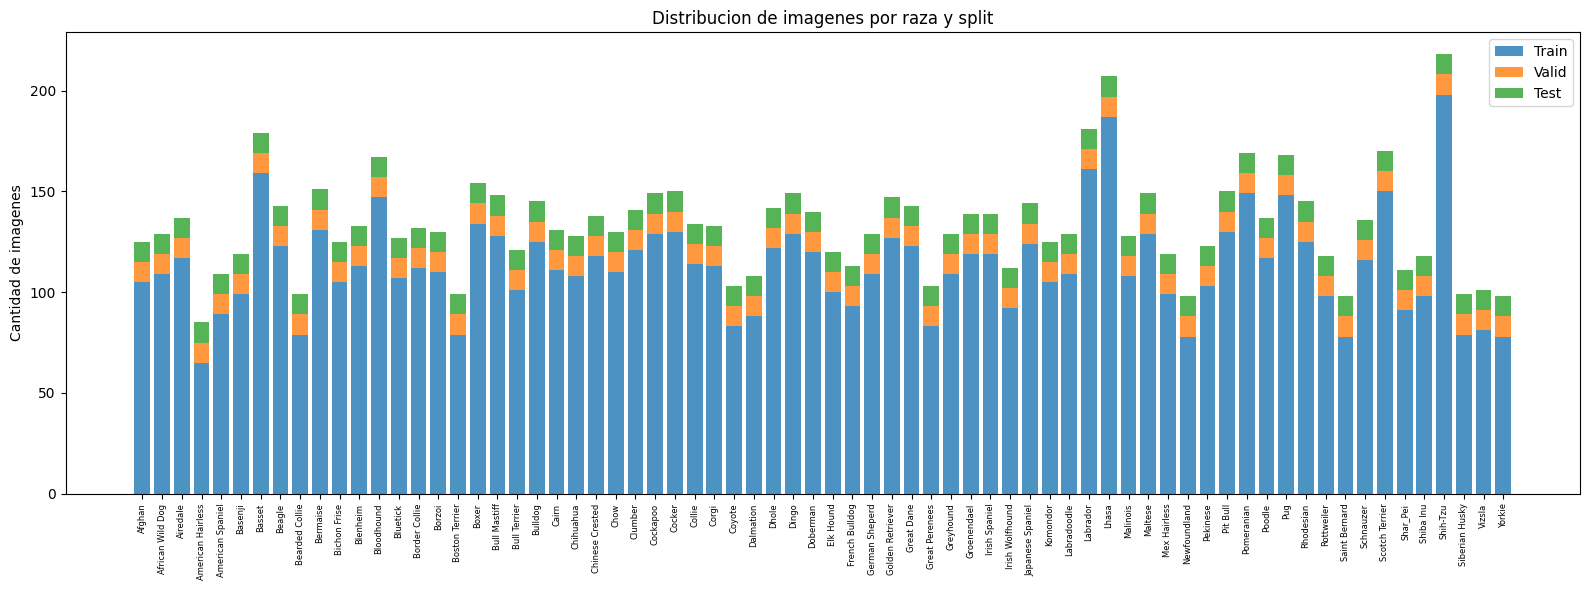


Filtrado de imagenes corruptas o de baja resolucion

Total imagenes revisadas: 9346
Corruptas: 0
Resolucion < 64px: 0
No se encontraron imagenes problematicas.


In [2]:
from collections import Counter
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd

splits = ["train", "valid", "test"]
split_counts = {}
total_all = 0
for split in splits:
    split_dir = settings.dataset_path / split
    breeds = sorted([d.name for d in split_dir.iterdir() if d.is_dir()])
    counts = []
    for breed in breeds:
        img_count = len(list((split_dir / breed).glob("*.*")))
        counts.append(img_count)
    split_counts[split] = dict(zip(breeds, counts))
    total_all += sum(counts)

print(f"Total de imagenes en TODO el dataset: {total_all}")
print(f"Cantidad de razas: {len(breeds)}")
print()

rows = []
for breed in split_counts["train"].keys():
    rows.append({
        "Raza": breed,
        "Train": split_counts["train"].get(breed, 0),
        "Valid": split_counts["valid"].get(breed, 0),
        "Test": split_counts["test"].get(breed, 0),
        "Total": sum(split_counts[s].get(breed, 0) for s in splits),
    })
df = pd.DataFrame(rows).sort_values("Total", ascending=False)

print(f"Promedio por raza: {df['Total'].mean():.1f}")
print(f"Mediana: {df['Total'].median():.0f}")
print(f"Minimo: {df['Total'].min()} ({(df['Total']==df['Total'].min()).sum()} raza(s))")
print(f"Maximo: {df['Total'].max()} ({(df['Total']==df['Total'].max()).sum()} raza(s))")
print()
print("Distribucion de clases (Top 5):")
print(df.head(5).to_string(index=False))
print()
print("Distribucion de clases (Bottom 5):")
print(df.tail(5).to_string(index=False))

# Bar plot apilado
fig, ax = plt.subplots(figsize=(16, 6))
df_sorted = df.sort_values("Raza")
x = range(len(df_sorted))
ax.bar(x, df_sorted["Train"], label="Train", alpha=0.8)
ax.bar(x, df_sorted["Valid"], bottom=df_sorted["Train"], label="Valid", alpha=0.8)
ax.bar(x, df_sorted["Test"], bottom=df_sorted["Train"] + df_sorted["Valid"], label="Test", alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(df_sorted["Raza"], rotation=90, fontsize=6)
ax.set_ylabel("Cantidad de imagenes")
ax.set_title("Distribucion de imagenes por raza y split")
ax.legend()
plt.tight_layout()
plt.show()

# Filtrado de imagenes corruptas o de baja resolucion
print("\n" + "=" * 50)
print("Filtrado de imagenes corruptas o de baja resolucion")
print("=" * 50)
from PIL import Image
min_dim = 64
corruptas = 0
baja_res = 0
total = 0
for split in ["train", "valid", "test"]:
    split_dir = settings.dataset_path / split
    for img_path in split_dir.rglob("*.*"):
        if img_path.suffix.lower() not in (".jpg", ".jpeg", ".png", ".bmp"):
            continue
        total += 1
        try:
            with Image.open(img_path) as im:
                if min(im.size) < min_dim:
                    baja_res += 1
                    if baja_res <= 5:
                        print(f"  Baja resolucion: {img_path.name} ({im.size[0]}x{im.size[1]})")
        except Exception:
            corruptas += 1
            if corruptas <= 5:
                print(f"  Corrupta: {img_path}")

print(f"\nTotal imagenes revisadas: {total}")
print(f"Corruptas: {corruptas}")
print(f"Resolucion < {min_dim}px: {baja_res}")
if corruptas == 0 and baja_res == 0:
    print("No se encontraron imagenes problematicas.")

### 2.1 Conjunto independiente de evaluacion

Ademas del split de test provisto, se construye un conjunto independiente con imagenes
descargadas de internet (por ejemplo, Google Images, Unsplash) para validar la capacidad
de generalizacion del sistema.

**Instrucciones:**
1. Crear una carpeta `data/external/` en la raiz del proyecto.
2. Colocar ~15 imagenes por raza (las 70 razas) descargadas manualmente.
3. Cada subcarpeta debe tener el nombre exacto de la raza (igual que en train/).
4. Ejecutar la celda siguiente para evaluar el modelo sobre este conjunto.

In [3]:
external_dir = settings.dataset_path.parent / "external"
if external_dir.is_dir():
    from torchvision import datasets
    from torch.utils.data import DataLoader
    import torch

    external_ds = datasets.ImageFolder(
        str(external_dir),
        transform=classifier._get_transforms(augment=False),
    )
    loader = DataLoader(external_ds, batch_size=32, shuffle=False)

    model = classifier.load_model().to("cuda" if torch.cuda.is_available() else "cpu")
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in loader:
            images = images.to("cuda" if torch.cuda.is_available() else "cpu")
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            correct += (preds.cpu() == labels).sum().item()
            total += labels.size(0)
    print(f"Accuracy en conjunto externo: {correct / total:.2%} ({correct}/{total})")
else:
    print("Carpeta data/external/ no encontrada. Crealá manualmente (ver instrucciones arriba).")

Carpeta data/external/ no encontrada. Crealá manualmente (ver instrucciones arriba).


## 3. Preprocesamiento

Se visualizan ejemplos de data augmentation aplicados a una imagen original:
HorizontalFlip, Rotacion, Blur, Ruido, y variaciones de brillo/contraste/saturacion.
El resize a 224x224 y la normalizacion (mean/std de ImageNet) se aplican en
el transform base del clasificador.

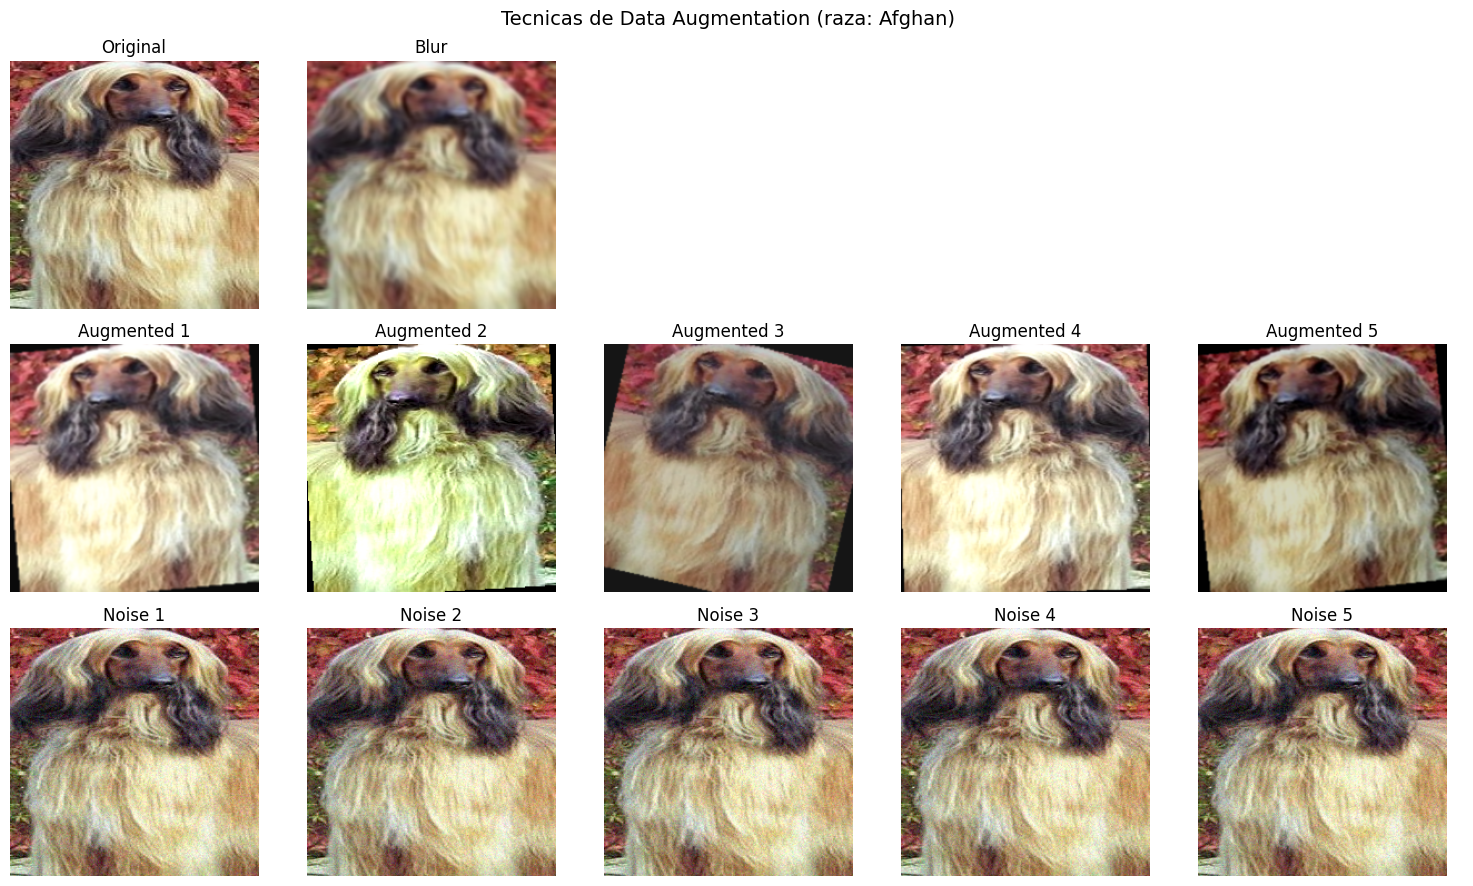

In [4]:
import torchvision.transforms as T
from PIL import Image
import numpy as np
import torch
import matplotlib.pyplot as plt

train_dir = settings.dataset_path / "train"
breeds = sorted([d.name for d in train_dir.iterdir() if d.is_dir()])
sample_breed = breeds[0]
sample_img_path = list((train_dir / sample_breed).glob("*.*"))[0]
img = Image.open(sample_img_path).convert("RGB")

# Transform con blur para mostrar
blur_transform = T.Compose([
    T.Resize((settings.image_size, settings.image_size)),
    T.GaussianBlur(kernel_size=5, sigma=(2.0, 3.0)),
])

# Transform completo (como en entrenamiento: flip, rotacion, color, blur) sin normalizar
augment_transform = T.Compose([
    T.Resize((settings.image_size, settings.image_size)),
    T.RandomHorizontalFlip(p=1.0),
    T.RandomRotation(degrees=15),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    T.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0)),
])

# Transform con ruido gaussiano (post-ToTensor)
def add_noise(t):
    return t + torch.randn_like(t) * 0.05

noise_transform = T.Compose([
    T.Resize((settings.image_size, settings.image_size)),
    T.ToTensor(),
    T.Lambda(add_noise),
])

def to_display(t):
    return np.clip(t.permute(1, 2, 0).numpy(), 0, 1)

fig, axes = plt.subplots(3, 5, figsize=(15, 9))
for i in range(5):
    # Fila 0: Original + Blur
    axes[0, 0].imshow(img)
    axes[0, 0].set_title("Original")
    axes[0, 0].axis("off")
    if i == 0:
        axes[0, 0].set_title("Original")
    if i > 0:
        axes[0, i].axis("off")
    axes[0, 1].imshow(blur_transform(img))
    axes[0, 1].set_title("Blur")
    axes[0, 1].axis("off")
    for j in range(2, 5):
        axes[0, j].axis("off")

    # Fila 1: Augmented (Flip + Rot + Color + Blur)
    aug_img = augment_transform(img)
    axes[1, i].imshow(aug_img)
    axes[1, i].set_title(f"Augmented {i+1}")
    axes[1, i].axis("off")

    # Fila 2: Ruido gaussiano
    noisy = noise_transform(img)
    axes[2, i].imshow(to_display(noisy))
    axes[2, i].set_title(f"Noise {i+1}")
    axes[2, i].axis("off")

axes[0, 0].set_ylabel("Blur / Original", fontsize=10)
axes[1, 0].set_ylabel("Augmented", fontsize=10)
axes[2, 0].set_ylabel("Noise", fontsize=10)
plt.suptitle(f"Tecnicas de Data Augmentation (raza: {sample_breed})", fontsize=14)
plt.tight_layout()
plt.show()

## 4. Modelo A (obligatorio): fine-tuning de ResNet18

`train_classifier` debe guardar el checkpoint en `models/resnet18_finetuned.pth`
(o el nombre configurado en RESNET18_MODEL_NAME). Documentar los hiperparametros
utilizados (learning rate, batch size, epochs, optimizador, scheduler).

In [5]:
from lib.bootstrap import build_classifier

classifier = build_classifier(settings)
classifier.set_active_model("resnet18_finetuned")
classifier.train_classifier()

INFO:lib.services.classifier_service:Entrenando modelo: resnet18_finetuned
INFO:lib.services.classifier_service:Dispositivo: cpu
INFO:lib.services.classifier_service:Epoch  1/15 — train_loss=1.8823 train_acc=0.6159 — valid_loss=0.5544 valid_acc=0.9143
INFO:lib.services.classifier_service:Checkpoint guardado: models/resnet18_finetuned.pth (valid_loss=0.5544)
INFO:lib.services.classifier_service:Epoch  2/15 — train_loss=0.6475 train_acc=0.8628 — valid_loss=0.2885 valid_acc=0.9371
INFO:lib.services.classifier_service:Checkpoint guardado: models/resnet18_finetuned.pth (valid_loss=0.2885)
INFO:lib.services.classifier_service:Epoch  3/15 — train_loss=0.3934 train_acc=0.9133 — valid_loss=0.2068 valid_acc=0.9543
INFO:lib.services.classifier_service:Checkpoint guardado: models/resnet18_finetuned.pth (valid_loss=0.2068)
INFO:lib.services.classifier_service:Epoch  4/15 — train_loss=0.2678 train_acc=0.9361 — valid_loss=0.1904 valid_acc=0.9457
INFO:lib.services.classifier_service:Checkpoint guardad

In [6]:
metrics_a = classifier.evaluate_classifier()
metrics_a

INFO:lib.services.classifier_service:Evaluando modelo: resnet18_finetuned
INFO:lib.services.classifier_service:Métricas: {'accuracy': 0.9714, 'precision': 0.9727, 'recall': 0.9714, 'specificity': 0.9996, 'f1': 0.9713}


{'accuracy': 0.9714,
 'precision': 0.9727,
 'recall': 0.9714,
 'specificity': 0.9996,
 'f1': 0.9713}

### Curvas de entrenamiento y matriz de confusion (Modelo A)

Se grafican las curvas de loss y accuracy para entrenamiento y validacion,
la matriz de confusion y el accuracy por clase para identificar las razas
con peor desempeno.

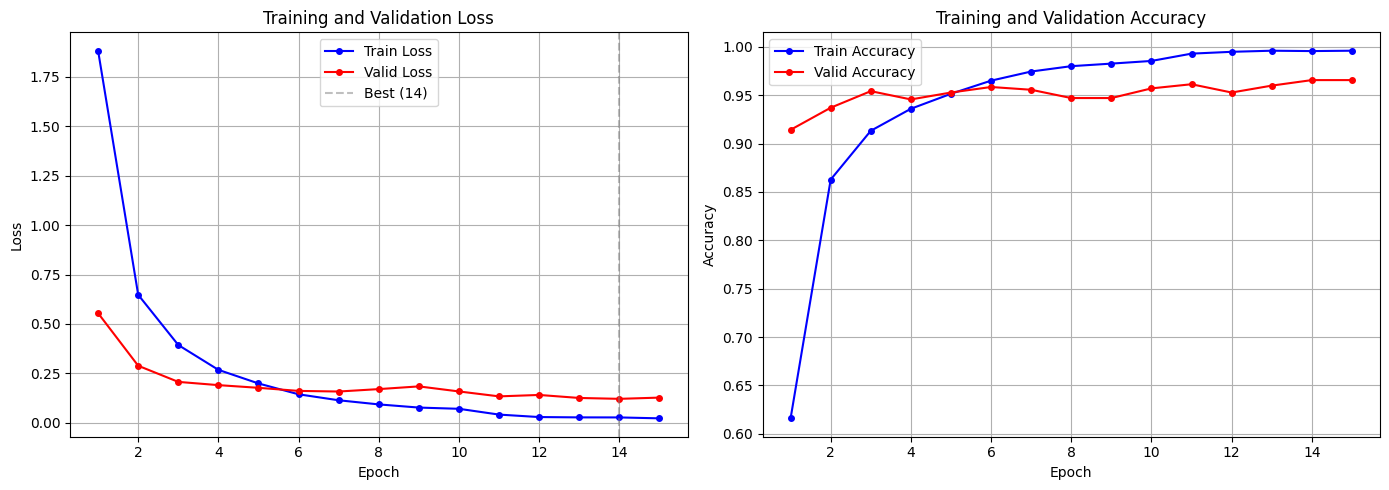

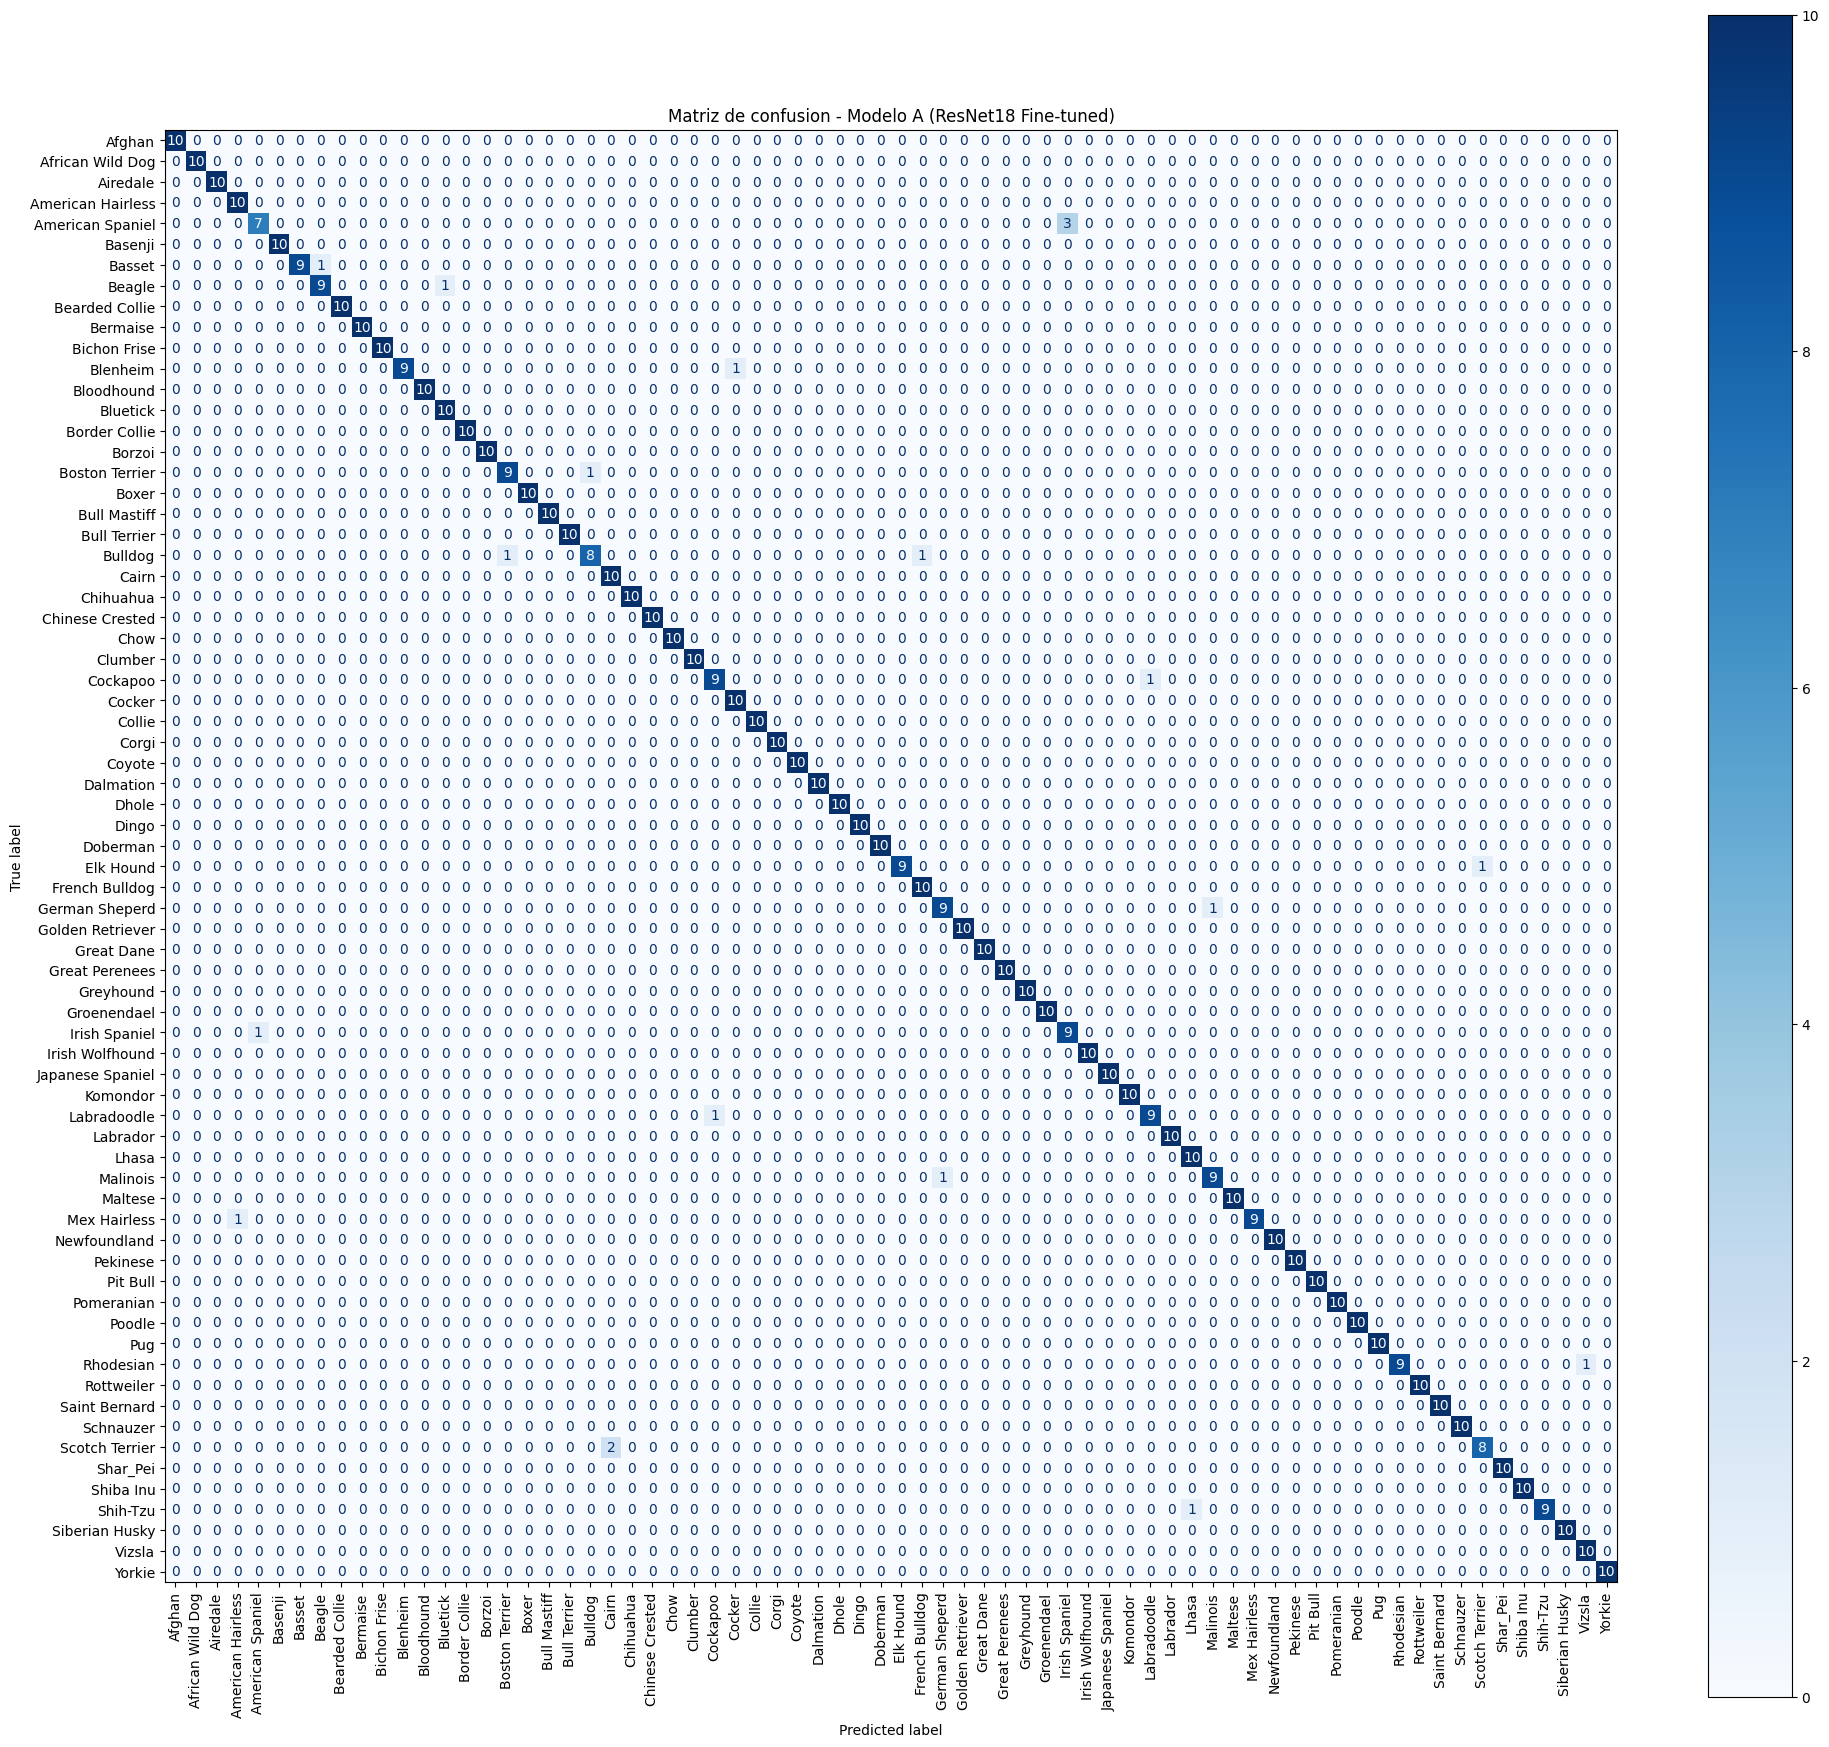

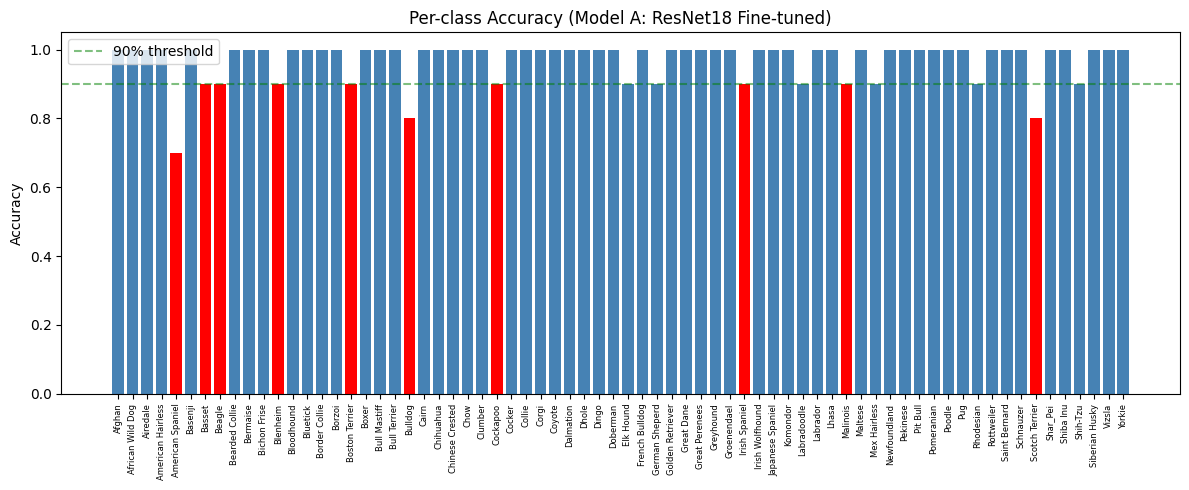


Razas con peor accuracy (Top 10):
  American Spaniel: 70.00% (7/10)
  Bulldog: 80.00% (8/10)
  Scotch Terrier: 80.00% (8/10)
  Beagle: 90.00% (9/10)
  Boston Terrier: 90.00% (9/10)
  Cockapoo: 90.00% (9/10)
  Blenheim: 90.00% (9/10)
  Basset: 90.00% (9/10)
  Irish Spaniel: 90.00% (9/10)
  Malinois: 90.00% (9/10)


In [7]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

history = classifier._train_history
epochs = range(1, len(history["train_loss"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs, history["train_loss"], "b-o", label="Train Loss", markersize=4)
axes[0].plot(epochs, history["valid_loss"], "r-o", label="Valid Loss", markersize=4)
best_epoch = np.argmin(history["valid_loss"])
axes[0].axvline(best_epoch + 1, color="gray", linestyle="--", alpha=0.5, label=f"Best ({best_epoch+1})")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Training and Validation Loss")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(epochs, history["train_acc"], "b-o", label="Train Accuracy", markersize=4)
axes[1].plot(epochs, history["valid_acc"], "r-o", label="Valid Accuracy", markersize=4)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Training and Validation Accuracy")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

# Matriz de confusion
class_names = classifier._eval_classes
cm = confusion_matrix(classifier._eval_labels, classifier._eval_preds)
plt.figure(figsize=(20, 18))
disp = ConfusionMatrixDisplay(cm, display_labels=class_names)
disp.plot(ax=plt.gca(), xticks_rotation=90, values_format="d", cmap="Blues")
plt.title("Matriz de confusion - Modelo A (ResNet18 Fine-tuned)")
plt.tight_layout()
plt.show()

# Per-class accuracy
correct_per_class = np.zeros(len(class_names))
total_per_class = np.zeros(len(class_names))
for true, pred in zip(classifier._eval_labels, classifier._eval_preds):
    total_per_class[true] += 1
    if true == pred:
        correct_per_class[true] += 1
class_acc = correct_per_class / np.maximum(total_per_class, 1)
worst_idx = np.argsort(class_acc)[:10]

fig, ax = plt.subplots(figsize=(12, 5))
colors = ["red" if i in worst_idx else "steelblue" for i in range(len(class_names))]
ax.bar(range(len(class_names)), class_acc, color=colors)
ax.set_xticks(range(len(class_names)))
ax.set_xticklabels(class_names, rotation=90, fontsize=6)
ax.set_ylabel("Accuracy")
ax.set_title("Per-class Accuracy (Model A: ResNet18 Fine-tuned)")
ax.axhline(y=0.9, color="green", linestyle="--", alpha=0.5, label="90% threshold")
ax.legend()
plt.tight_layout()
plt.show()

print("\nRazas con peor accuracy (Top 10):")
for idx in worst_idx:
    print(f"  {class_names[idx]}: {class_acc[idx]:.2%} ({int(correct_per_class[idx])}/{int(total_per_class[idx])})")

## 5. Modelo B (opcional, recomendado): CNN propia

`train_classifier` con el modelo activo `cnn_custom` debe guardar el checkpoint en
`models/cnn_custom.pth` (o el nombre configurado en CNN_CUSTOM_MODEL_NAME).

In [8]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class ResidualBlock(nn.Module):
    def __init__(self, in_channels: int, out_channels: int, stride: int = 1) -> None:
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, 3, stride, 1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, 3, 1, 1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        shortcut: list[nn.Module] = []
        if stride != 1 or in_channels != out_channels:
            shortcut = [
                nn.Conv2d(in_channels, out_channels, 1, stride, bias=False),
                nn.BatchNorm2d(out_channels),
            ]
        self.shortcut = nn.Sequential(*shortcut)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        return F.relu(out)


class CustomCNN(nn.Module):
    def __init__(self, num_classes: int, embed_dim: int = 512) -> None:
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 64, 3, 1, 1, bias=False), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
            ResidualBlock(64, 64, 1),
            ResidualBlock(64, 128, 2),
            ResidualBlock(128, 256, 2),
            ResidualBlock(256, 512, 2),
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Dropout(0.5),
            nn.Linear(512, embed_dim),
            nn.ReLU(),
        )
        self.classifier = nn.Linear(embed_dim, num_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.classifier(self.features(x))


print("Arquitectura CustomCNN definida.")
print(CustomCNN(num_classes=70))
print(f"Parametros: {sum(p.numel() for p in CustomCNN(num_classes=70).parameters()):,}")

Arquitectura CustomCNN definida.
CustomCNN(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): ResidualBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (shortcut): Sequential()
    )
    (5): ResidualBlock(
      (conv1): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (con

In [ ]:
classifier.set_active_model("cnn_custom")
classifier.train_classifier()
metrics_b = classifier.evaluate_classifier()
metrics_b

INFO:lib.services.classifier_service:Entrenando modelo: cnn_custom
INFO:lib.services.classifier_service:Dispositivo: cpu
INFO:lib.services.classifier_service:Epoch  1/15 — train_loss=4.0463 train_acc=0.0403 — valid_loss=4.0121 valid_acc=0.0571
INFO:lib.services.classifier_service:Checkpoint guardado: models/cnn_custom.pth (valid_loss=4.0121)
INFO:lib.services.classifier_service:Epoch  2/15 — train_loss=3.8551 train_acc=0.0603 — valid_loss=3.5926 valid_acc=0.0886
INFO:lib.services.classifier_service:Checkpoint guardado: models/cnn_custom.pth (valid_loss=3.5926)


In [ ]:
# Se obtienen los datos del historial y evaluación correspondientes al modelo activo (cnn_custom)
history = classifier._train_history
epochs = range(1, len(history["train_loss"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs, history["train_loss"], "b-o", label="Train Loss", markersize=4)
axes[0].plot(epochs, history["valid_loss"], "r-o", label="Valid Loss", markersize=4)
best_epoch = np.argmin(history["valid_loss"])
axes[0].axvline(best_epoch + 1, color="gray", linestyle="--", alpha=0.5, label=f"Best ({best_epoch+1})")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Training and Validation Loss")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(epochs, history["train_acc"], "b-o", label="Train Accuracy", markersize=4)
axes[1].plot(epochs, history["valid_acc"], "r-o", label="Valid Accuracy", markersize=4)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Training and Validation Accuracy")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

# Matriz de confusión
cm = confusion_matrix(classifier._eval_labels, classifier._eval_preds)
plt.figure(figsize=(20, 18))
disp = ConfusionMatrixDisplay(cm, display_labels=class_names)
disp.plot(ax=plt.gca(), xticks_rotation=90, values_format="d", cmap="Blues")
plt.title("Matriz de confusión - Modelo B (CustomCNN)")
plt.tight_layout()
plt.show()

# Per-class accuracy
correct_per_class = np.zeros(len(class_names))
total_per_class = np.zeros(len(class_names))
for true, pred in zip(classifier._eval_labels, classifier._eval_preds):
    total_per_class[true] += 1
    if true == pred:
        correct_per_class[true] += 1
class_acc = correct_per_class / np.maximum(total_per_class, 1)
worst_idx = np.argsort(class_acc)[:10]

fig, ax = plt.subplots(figsize=(12, 5))
colors = ["red" if i in worst_idx else "steelblue" for i in range(len(class_names))]
ax.bar(range(len(class_names)), class_acc, color=colors)
ax.set_xticks(range(len(class_names)))
ax.set_xticklabels(class_names, rotation=90, fontsize=6)
ax.set_ylabel("Accuracy")
ax.set_title("Per-class Accuracy (Model B: CustomCNN)")
ax.axhline(y=0.4, color="green", linestyle="--", alpha=0.5, label="40% threshold")
ax.legend()
plt.tight_layout()
plt.show()

print("\nRazas con peor accuracy (Top 10):")
for idx in worst_idx:
    print(f"  {class_names[idx]}: {class_acc[idx]:.2%} ({int(correct_per_class[idx])}/{int(total_per_class[idx])})")

## 6. Estudio comparativo

Se comparan las metricas de los modelos entrenados: accuracy, precision, recall,
specificity y F1. Se analizan los pares (verdadera -> predicha) mas frecuentes
en los errores para identificar confusiones sistematicas entre razas.

In [ ]:
import pandas as pd

try:
    metrics_b
except NameError:
    metrics_b = None

data = {
    "Metrica": ["Accuracy", "Precision (macro)", "Recall (macro)", "Specificity (macro)", "F1-Score (macro)"],
    "ResNet18 Fine-tuned": [
        f"{metrics_a['accuracy']:.2%}",
        f"{metrics_a['precision']:.2%}",
        f"{metrics_a['recall']:.2%}",
        f"{metrics_a['specificity']:.2%}",
        f"{metrics_a['f1']:.2%}",
    ],
}
if metrics_b:
    data["CustomCNN"] = [
        f"{metrics_b['accuracy']:.2%}",
        f"{metrics_b['precision']:.2%}",
        f"{metrics_b['recall']:.2%}",
        f"{metrics_b['specificity']:.2%}",
        f"{metrics_b['f1']:.2%}",
    ]
df_comp = pd.DataFrame(data)
print(df_comp.to_string(index=False))

print("\n--- Analisis de errores ---")
class_names = classifier._eval_classes
errors = []
for true, pred in zip(classifier._eval_labels, classifier._eval_preds):
    if true != pred:
        errors.append((class_names[true], class_names[pred]))
print(f"Total de errores: {len(errors)} de {len(classifier._eval_labels)} ({len(errors)/len(classifier._eval_labels):.1%})")
print("\nPares (verdadera -> predicha) mas frecuentes:")
from collections import Counter
for (true, pred), count in Counter(errors).most_common(10):
    print(f"  {true} -> {pred}: {count} veces")

            Metrica ResNet18 Fine-tuned CustomCNN
           Accuracy              97.14%    43.71%
  Precision (macro)              97.35%    42.92%
     Recall (macro)              97.14%    43.71%
Specificity (macro)              99.96%    99.18%
   F1-Score (macro)              97.16%    40.37%

--- Analisis de errores ---
Total de errores: 394 de 700 (56.3%)

Pares (verdadera -> predicha) mas frecuentes:
  Basset -> Saint Bernard: 4 veces
  Great Dane -> Pug: 4 veces
  Lhasa -> Pekinese: 4 veces
  Newfoundland -> Afghan: 4 veces
  African Wild Dog -> German Sheperd: 3 veces
  American Spaniel -> Irish Spaniel: 3 veces
  Bichon Frise -> Bull Terrier: 3 veces
  Blenheim -> Collie: 3 veces
  Borzoi -> Collie: 3 veces
  Boston Terrier -> Border Collie: 3 veces


Añadir grafico de barras 